In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models,datasets
import numpy as np

In [7]:
# mnist에서 제공한 fashion 예제
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

In [ ]:
# X_test, y_test를 이용해서 평가를 하고, X_test, y_test 중 16개를 가져와서 예측
# 학습은 1에포크만 적용(이유 시간 때문에)
# 분류는 총 10개


In [9]:
# 예측을 하면 분류 수만큼 확률이 나옴
# 왜? 모델 설계에서 출력층 활성화 함수가 softmax
# 가장 확률이 높은 분류 번호 => 타이틀
class_names = [
	'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
	'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
# 콜백
callbacks = [
	# 조기 종료
	EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
	# 가장 좋았던 성능을 저장 => 중간에 중지해도 중지전까지 최고 성능을 가져옴
	ModelCheckpoint(filepath='best_fs_mnist_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
	# 학습률을 고정 값이 아닌 상황에 따라 줄어들도록 조절
	ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

In [12]:
X_train.shape

(60000, 28, 28)

In [13]:
# 파이프라인 : 성능 향상 <= 학습 중에 다음 학습 데이터를 준비 
from tensorflow.data import Dataset

DATASET_SIZE = 60000
TRAIN_SIZE = int(DATASET_SIZE * 0.8)
VAL_SIZE = int(DATASET_SIZE * 0.2)

dataset = Dataset.from_tensor_slices((X_train, y_train))
# 섞음 
dataset = dataset.shuffle(buffer_size=DATASET_SIZE)
# 훈련 데이터셋
train_dataset = dataset.take(TRAIN_SIZE)
# 검증 데이터셋
val_dataset = dataset.skip(TRAIN_SIZE)

train_dataset = train_dataset.batch(128).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

In [14]:
# 데이터 증강 => 다양한 형태의 이미지를 준비하지 않아도 생성해서 학습할 수 있도록 
data_augmentation = tf.keras.Sequential([
	tf.keras.layers.RandomFlip("horizontal"), # 좌우 반전
	tf.keras.layers.RandomRotation(0.2) # 20% 범위 내에서 무작위 회전
])

In [15]:
# 모델 설계
model = tf.keras.models.Sequential([
	tf.keras.Input((28, 28, 1)),
	# 데이터 증강 
	data_augmentation, 
	# 정규화
	tf.keras.layers.Rescaling(1./255),

	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	# tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),
	# 이 때 이미지 크기 16 x 16

	# 블록 2
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	# tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),
	# 이 때 이미지 크기 8 x 8

	# 블록 3
	# tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.GlobalAveragePooling2D(),

	# 분류기
	tf.keras.layers.Dense(10, activation='softmax')
])

In [16]:
# 모델 설정
model.compile(
	optimizer='adam', 
	loss='sparse_categorical_crossentropy', 
	metrics=['accuracy']
)

In [ ]:
# 학습
history = model.fit(
	train_dataset,
	epochs = 30,
	verbose = 1,
	validation_data=val_dataset,
	callbacks = callbacks,
	batch_size=128,
)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4226 - loss: 1.6620
Epoch 1: val_accuracy improved from None to 0.12442, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 85ms/step - accuracy: 0.5239 - loss: 1.4211 - val_accuracy: 0.1244 - val_loss: 3.0562 - learning_rate: 0.0010


In [18]:
# 평가
_, acc = model.evaluate(X_test, y_test)
print(f'정확도 : {acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1261 - loss: 3.0384
정확도 : 0.12610000371932983


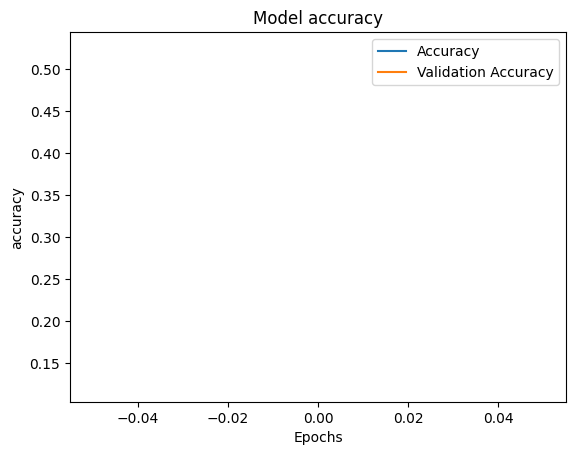

In [19]:
# 성능 시각화
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [24]:
y_test

array([9, 2, 1, ..., 8, 1, 5], shape=(10000,), dtype=uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


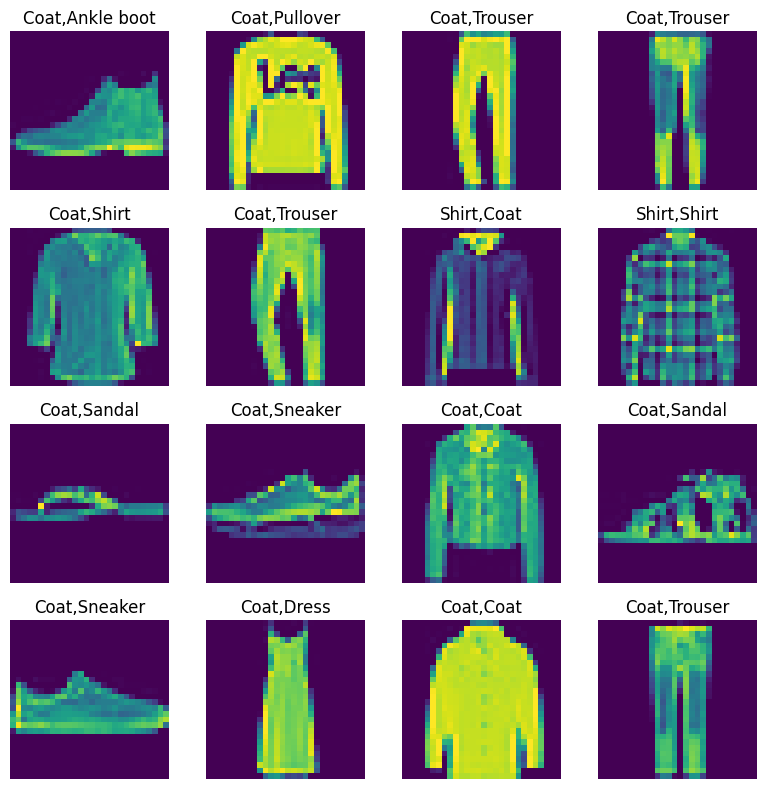

In [28]:
# 이미지 시각화
predictions = model.predict(X_test[:16])
fig, axes = plt.subplots(4, 4, figsize=(8,8))
for i, ax in enumerate(axes.flat):
	ax.imshow(X_test[i])
	predict_idx = predictions[i].argmax() # 확률이 가장 높은 값(번지)
	predict_name = class_names[predict_idx] # 확률이 가장 높은 분류명

	real_idx = y_test[i] # 실제 값(번지)
	real_name = class_names[real_idx] # 실제 분류명
	ax.set_title(f"{predict_name},{real_name}")
	ax.axis('off')

plt.tight_layout()
plt.show()